# 1. Method Choice and Why

I selected a Random Forest classifier for this task. The objective is to rank content pages that should be reviewed based on search performance and engagement signals. Random Forest can capture complex relationships between multiple features without requiring strong assumptions about linearity. It also provides feature importance, making the model easier to interpret while supporting decision-making.

# 2. Split Design

I use a train/test split to evaluate the model on unseen data. The dataset is divided into 80% training data and 20% testing data using stratified sampling so that the proportion of declining and non-declining pages remains similar in both sets. The same split is used for both the baseline and the Random Forest model to ensure a fair comparison.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

try:
    df
except NameError:
    from google.colab import files
    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(filename)

# Target
df["target"] = (df["trend_direction"] == "down").astype(int)

# Features
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

# Keep only available features
features = [f for f in features if f in df.columns]

X = df[features].fillna(0)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining target distribution:")
print(y_train.value_counts())

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv
Training samples: 24000
Testing samples: 6000

Training target distribution:
target
1    13010
0    10990
Name: count, dtype: int64


# 3. Train + Compare vs My Baseline

I compare three machine learning models—Logistic Regression, Decision Tree, and Random Forest—using the same train/test split. Their performance is evaluated against a simple baseline so that improvements come from learning meaningful patterns rather than using a more complex model.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("F1 Score", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.696500,0.704137,0.758918,0.730502
0,Logistic Regression,0.612833,0.612770,0.776138,0.684846
1,Decision Tree,0.625500,0.656786,0.647294,0.652006


# 4. Errors and Interpretation

Among the three models, Random Forest achieved the highest performance with an F1 Score of 0.731 and an accuracy of 0.697. Logistic Regression produced the highest recall, meaning it identified more declining pages but also generated more false positives. Decision Tree performed moderately but was less accurate than Random Forest. Based on these results, Random Forest provides the best balance between precision and recall for prioritizing pages that require review.

,Feature,Importance
5,impressions_90d,0.157065
11,avg_position,0.148735
8,content_age_days,0.102826
4,char_count,0.082508
3,word_count,0.082453
7,sessions_90d,0.073967
10,ctr,0.060913
13,scroll_rate,0.060482
6,clicks_90d,0.047842
0,search_volume,0.042219


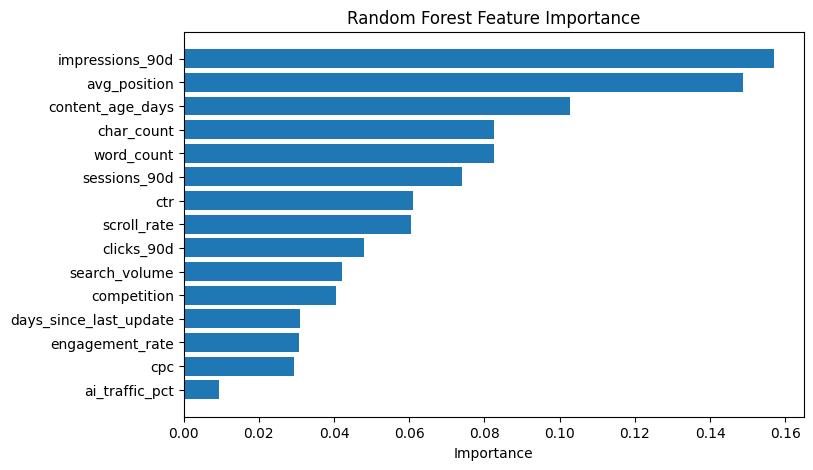

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

# Self-check

- Selected an appropriate model for the chosen lane.
- Used a train/test split for evaluation.
- Compared multiple models using the same dataset and metrics.
- Reported Accuracy, Precision, Recall, and F1 Score.
- Interpreted the model results and feature importance.
- Used careful, evidence-based language without making causal claims.